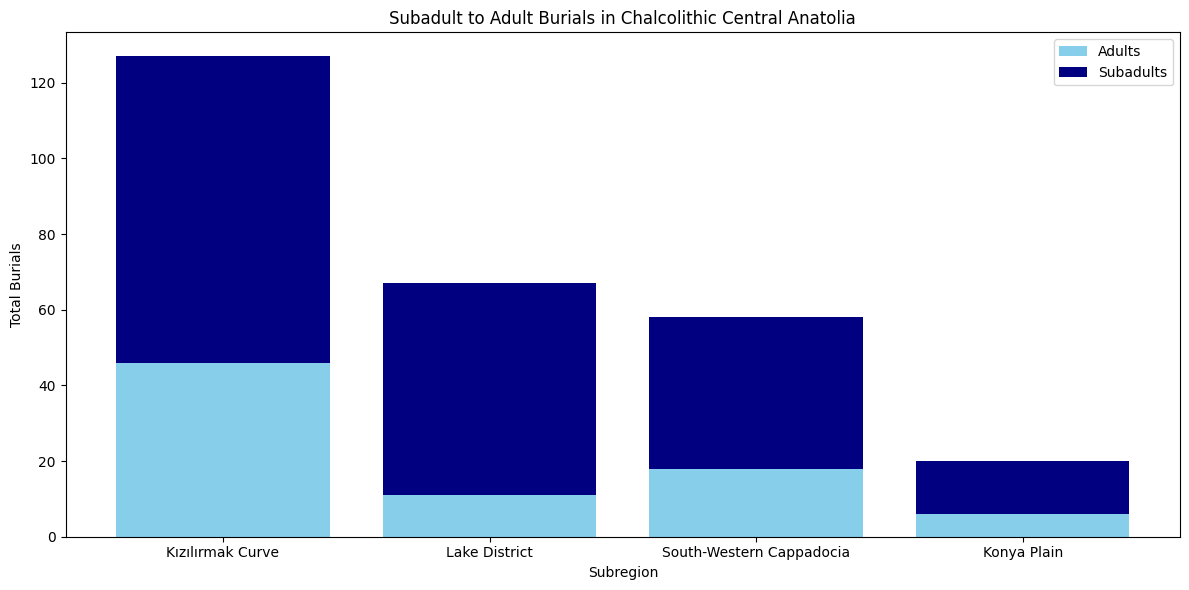

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12,6))

subregion= ['Kızılırmak Curve', 'Lake District', 'South-Western Cappadocia', 'Konya Plain',]
adults = [46, 11, 18, 6]
subadults = [81, 56, 40, 14]
adults_normalized= [46/(46+81), 11/(11+56), 18/(18+40), 6/(6+14)]
subadults_normalized= [81/(46+81), 56/(11+56), 40/(18+40), 14/(6+14)]

# Bar 1
ax.bar(subregion, adults, color='skyblue', label='Adults')
# Bar 2 Stacked
ax.bar(subregion, subadults, bottom=adults, color='navy', label='Subadults') # illustrating: bottom
ax.set_title("Subadult to Adult Burials in Chalcolithic Central Anatolia", size= 12)
ax.set_xlabel("Subregion")
ax.set_ylabel("Total Burials")
ax.legend()

fig.tight_layout()
plt.show()


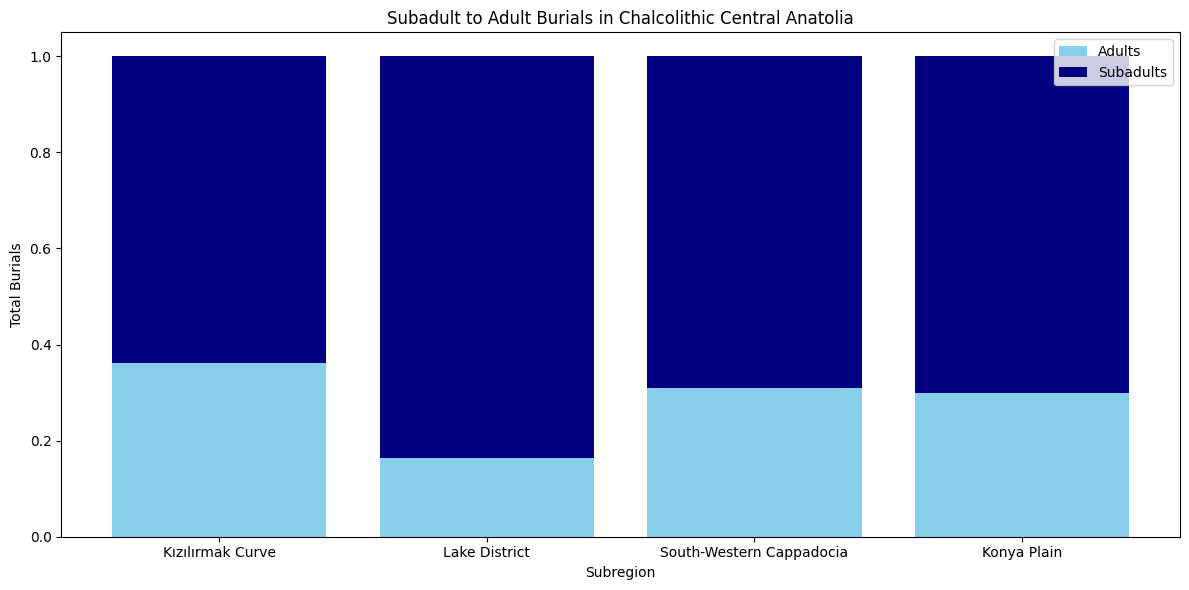

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12,6))

subregion= ['Kızılırmak Curve', 'Lake District', 'South-Western Cappadocia', 'Konya Plain',]
adults = [46, 11, 18, 6]
subadults = [81, 56, 40, 14]
adults_normalized= [46/(46+81), 11/(11+56), 18/(18+40), 6/(6+14)]
subadults_normalized= [81/(46+81), 56/(11+56), 40/(18+40), 14/(6+14)]
total_burials= [(46+81)/272, (11+56)/272, (18+40)/272, (6+14)/272]

# Bar 1
ax.bar(subregion, adults_normalized, color='skyblue', label='Adults') #width=total_burials)
# Bar 2 Stacked
ax.bar(subregion, subadults_normalized, bottom=adults_normalized, color='navy', label='Subadults') #width=total_burials) # illustrating: bottom
#ax.set_xticks([0, 0.25, 0.50, 0.75, 1])
ax.set_title("Subadult to Adult Burials in Chalcolithic Central Anatolia", size= 12)
ax.set_xlabel("Subregion")
ax.set_ylabel("Total Burials")
ax.legend()

fig.tight_layout()
plt.show()


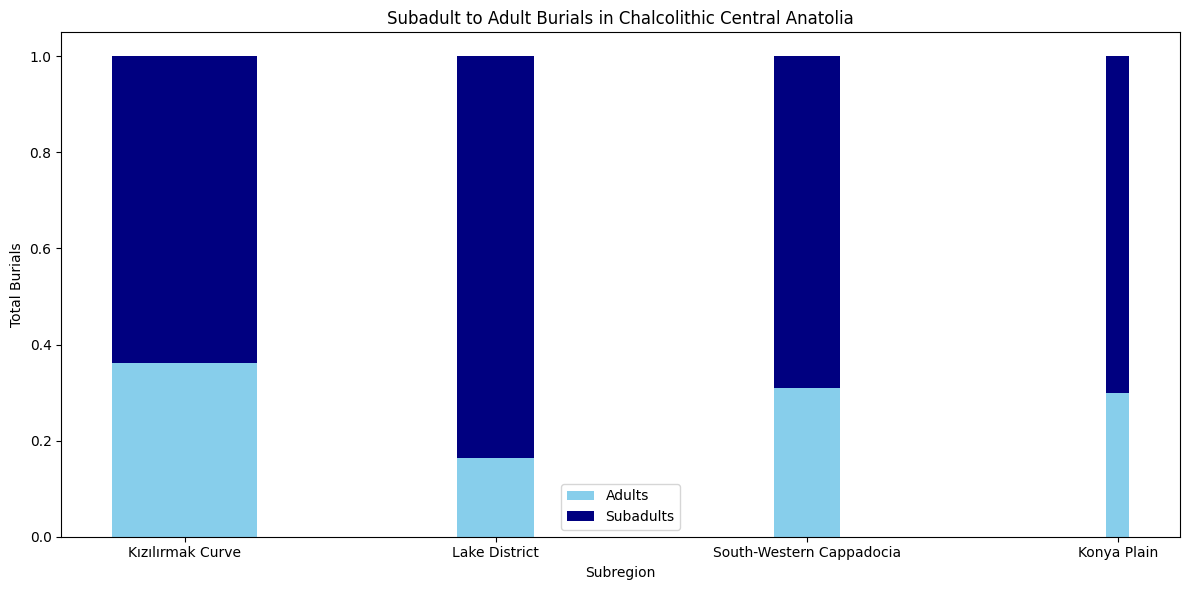

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12,6))

subregion= ['Kızılırmak Curve', 'Lake District', 'South-Western Cappadocia', 'Konya Plain',]
adults = [46, 11, 18, 6]
subadults = [81, 56, 40, 14]
adults_normalized= [46/(46+81), 11/(11+56), 18/(18+40), 6/(6+14)]
subadults_normalized= [81/(46+81), 56/(11+56), 40/(18+40), 14/(6+14)]
total_burials= [(46+81)/272, (11+56)/272, (18+40)/272, (6+14)/272]

# Bar 1
ax.bar(subregion, adults_normalized, color='skyblue', label='Adults', width= total_burials) #width=total_burials)
# Bar 2 Stacked
ax.bar(subregion, subadults_normalized, bottom=adults_normalized, color='navy', label='Subadults', width= total_burials) #width=total_burials) # illustrating: bottom
#ax.set_xticks([0, 0.25, 0.50, 0.75, 1])
ax.set_title("Subadult to Adult Burials in Chalcolithic Central Anatolia", size= 12)
ax.set_xlabel("Subregion")
ax.set_ylabel("Total Burials")
ax.legend()

fig.tight_layout()
plt.show()


In [4]:

import plotly.graph_objects as go
import numpy as np
import pandas as pd

subregion= ['Kızılırmak Curve', 'Lake District', 'South-Western Cappadocia', 'Konya Plain']
data = {'Adults': [46, 11, 18, 6],
       'Subadults': [81, 56, 40, 14],
       }

df = pd.DataFrame.from_dict(data)

df = df.T
df.columns = subregion
for c in df.columns:
    df[c+'_%'] = df[c].apply(lambda x: (x / df.loc[:,c].sum()) * 100)

widths = np.array([sum(df['Kızılırmak Curve']), sum(df['Lake District']), sum(df['South-Western Cappadocia']), sum(df['Konya Plain'])])
marker_colors = {'Adults': 'darkblue', 'Subadults': 'darkgreen'}

fig1 = go.Figure()

for idx in df.index:
    dff = df.filter(items=[idx], axis=0)
    fig1.add_trace(go.Bar(
        x=np.cumsum(widths),
        y=dff[dff.columns[4:]].values[0],
        width=widths,
        marker_color=marker_colors[idx],
        text=['{:.2f}%'.format(x) for x in dff[dff.columns[4:]].values[0]],
        name=idx
    )
)

fig1.update_xaxes(
    tickvals=np.cumsum(widths),
    ticktext= ["%s<br>%d" % (l, w) for l, w in zip(subregion, widths)]
)

fig1.update_xaxes(range=[0, widths])
fig1.update_yaxes(range=[0, 100])

fig1.update_layout(barmode='stack')

#fig1.write_image('test_1.png')
fig1.show()

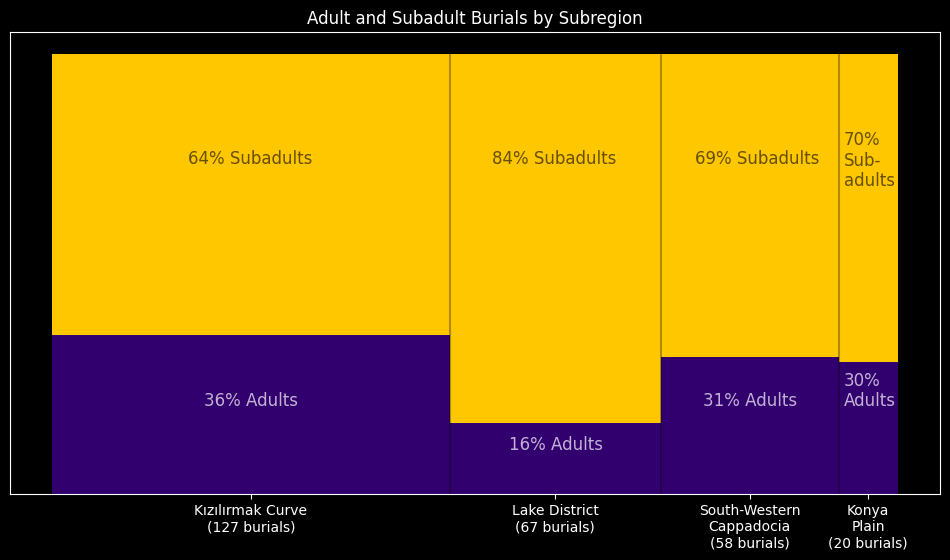

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

from matplotlib.patches import StepPatch
with plt.style.context('dark_background'):
    #plt.rcParams["axes.prop_cycle"] = cycler('color', ['#8B4513', '#CD853F', '#556B2F', '#708090', '#A0522D'])
    plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#FFC700', '#4B2E83', '#B7A57A'])
    fig, ax = plt.subplots(figsize=(12,6))
    
    A = [[0, 0, 0, 0],
         [0.36, 0.16, 0.31, 0.30],
         [1, 1, 1, 1]]
    edges= [0, 0.47, 0.72, 0.93, 1]
    
    #Generate Chart
    for i in range(len(A) - 1):
        plt.stairs(A[i+1], baseline=A[i], edges=edges, fill=True)
        
    #Insert Vertical Divider Lines
    ax.axvline(x=0.47, color='black', linestyle='-', alpha=0.3)
    ax.axvline(x=0.72, color='black', linestyle='-', alpha=0.3)
    ax.axvline(x=0.93, color='black', linestyle='-', alpha=0.3)
    
    #Hide axis
    ax.yaxis.set_visible(False)
    # ax.xaxis.set_visible(False)
    # ax.spines['top'].set_linewidth(0)
    # ax.spines['bottom'].set_linewidth(0)
    # ax.spines['left'].set_linewidth(0)
    # ax.spines['right'].set_linewidth(0)
    
    #Set Labels    
    ax.set_title('Adult and Subadult Burials by Subregion')
    ax.set_xticks([0.235, 0.595, 0.825, 0.965])
    ax.set_xticklabels(['Kızılırmak Curve\n(127 burials)', 'Lake District\n(67 burials)', 'South-Western\nCappadocia\n(58 burials)', 'Konya\nPlain\n(20 burials)'])
    # ax.tick_params(axis='x', labelrotation=45)
    ax.tick_params(axis='x', labelsize=10)

    #Add annotation
    ax.annotate('64% Subadults', 
            xy=(0.16, .75),
            size=12, color='black', alpha=0.6
            )
    ax.annotate('36% Adults', 
            xy=(0.18, .20),
            size=12, alpha=0.7
            )
    ax.annotate('84% Subadults', 
            xy=(0.52, .75),
            size=12, color='black', alpha=0.6
            )
    ax.annotate('16% Adults', 
            xy=(0.54, .10),
            size=12, alpha=0.7
            )
    ax.annotate('69% Subadults', 
            xy=(0.76, .75),
            size=12, color='black', alpha=0.6
            )
    ax.annotate('31% Adults', 
            xy=(0.77, .20),
            size=12, alpha=0.7
            )
    ax.annotate('70%\nSub-\nadults', 
            xy=(0.936, .70),
            size=12, color='black', alpha=0.6
            )
    ax.annotate('30%\nAdults', 
            xy=(0.936, .20),
            size=12, alpha=0.7
            )
    
    plt.show()

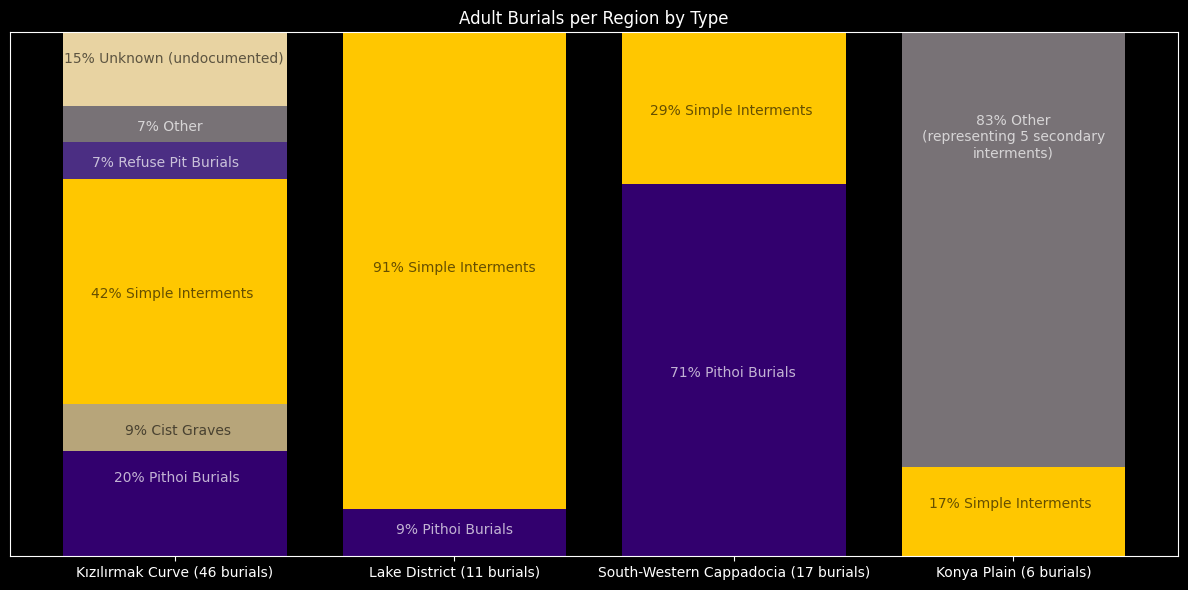

In [6]:
import matplotlib.pyplot as plt
import numpy as np

with plt.style.context('dark_background'):
    plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
    fig, ax = plt.subplots(figsize=(12,6))
    
    subregion= ['Kızılırmak Curve (46 burials)', 'Lake District (11 burials)', 'South-Western Cappadocia (17 burials)', 'Konya Plain (6 burials)']
    adults = [46, 11, 18, 6]
    subadults = [81, 56, 40, 14]
    adults_normalized= [46/(46+81), 11/(11+56), 18/(18+40), 6/(6+14)]
    subadults_normalized= [81/(46+81), 56/(11+56), 40/(18+40), 14/(6+14)]
    total_burials= [(46+81)/272, (11+56)/272, (18+40)/272, (6+14)/272]
    adult_burial_type = [[9, 1, 12, 0], [4, 0, 0, 0], [20, 10, 5, 1], [3, 0, 0, 0], [3, 0, 0, 5], [7, 0, 0, 0]]
    
    adult_pithos= np.array([0.2, 0.09, 0.71, 0.0])
    adult_cist= np.array([0.09, 0, 0, 0])
    adult_simple= np.array([0.43, 0.91, 0.29, 0.17])
    adult_refuse= np.array([0.07, 0, 0, 0])
    adult_other= np.array([0.07, 0, 0, 0.83])
    adult_unknown= np.array([0.14, 0, 0, 0])
    
    # Bar 1
    ax.bar(subregion, adult_pithos,label='Pithos Burial') #width=total_burials)
    # Bar 2 Stacked
    ax.bar(subregion, adult_cist, bottom=adult_pithos, label='Cist Grave') #width=total_burials) # illustrating: bottom
    #ax.set_xticks([0, 0.25, 0.50, 0.75, 1])
    ax.bar(subregion, adult_simple, bottom=adult_pithos + adult_cist, label='Simple Interment')
    ax.bar(subregion, adult_refuse, bottom=adult_simple + adult_pithos + adult_cist, label='Refuse Pit')
    ax.bar(subregion, adult_other, bottom=adult_refuse + adult_simple + adult_pithos + adult_cist, label='Other')
    ax.bar(subregion, adult_unknown, bottom=adult_other + adult_refuse + adult_simple + adult_pithos + adult_cist, label='Unknown')
    ax.set_title("Adult Burials per Region by Type", size= 12)
    ax.yaxis.set_visible(False)
    #ax.legend()


    #Labels Kızılırmak Curve
    ax.text(0.23, 
            0.15,
            '20% Pithoi Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(0.20, 
            0.24,
            '9% Cist Graves',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(0.28, 
            0.50,
            '42% Simple Interments',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(0.23, 
            0.75,
            '7% Refuse Pit Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(0.10, 
            0.82,
            '7% Other',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(0.39, 
            0.95,
            '15% Unknown (undocumented)',
            color='black', ha='right', va='center', alpha=0.6)

    #Labels Lake District
    ax.text(1.21, 
            0.05,
            '9% Pithoi Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(1.29, 
            0.55,
            '91% Simple Interments',
            color='Black', ha='right', va='center', alpha=0.6)

    #Labels South-Western Cappadocia
    ax.text(2.22,
            0.35,
            '71% Pithoi Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(2.28,
            0.85,
            '29% Simple Interments',
            color='black', ha='right', va='center', alpha=0.6)

    #Labels Konya Plain
    ax.text(3.28,
            0.10,
            '17% Simple Interments',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(3,
            0.80,
            '83% Other\n(representing 5 secondary\ninterments)',
            color='white', ha='center', va='center', alpha=0.7)


    fig.tight_layout()
    plt.show()

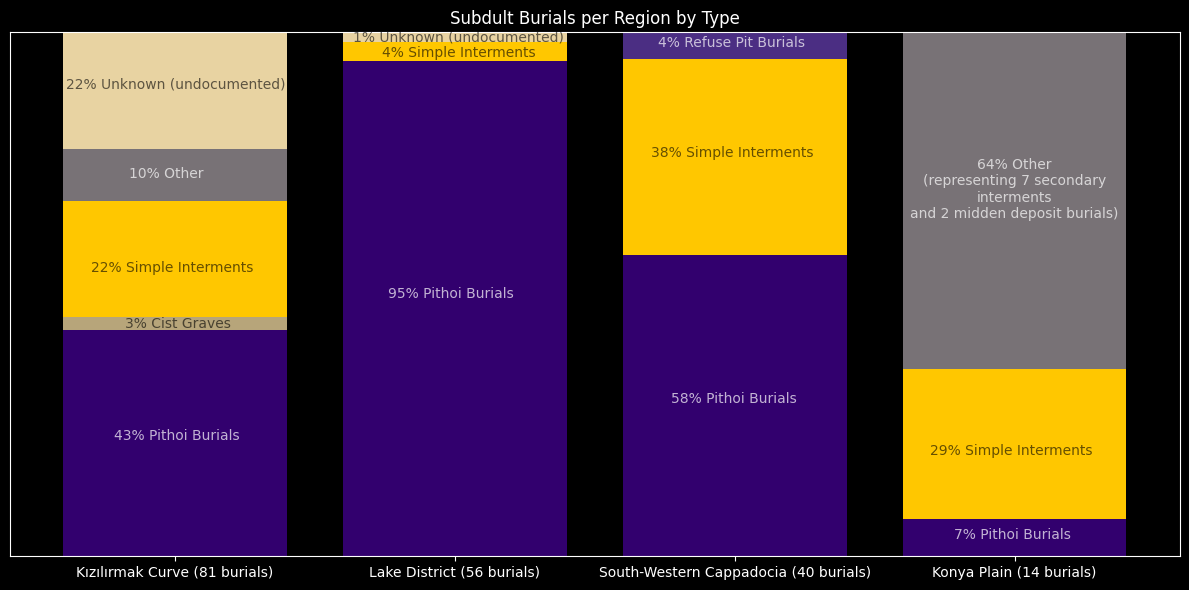

In [7]:
with plt.style.context('dark_background'):
    plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
    fig, ax = plt.subplots(figsize=(12,6))

    subregion= ['Kızılırmak Curve (81 burials)', 'Lake District (56 burials)', 'South-Western Cappadocia (40 burials)', 'Konya Plain (14 burials)']

    subadult_pithos= np.array([0.432, 0.946, 0.575, 0.071])
    subadult_cist= np.array([0.025, 0, 0, 0])
    subadult_simple= np.array([0.222, 0.036, 0.375, 0.286])
    subadult_refuse= np.array([0, 0, 0.05, 0])
    subadult_other= np.array([0.099, 0, 0, 0.643])
    subadult_unknown= np.array([0.221, 0.018, 0, 0])
    
    # Bar 1
    ax.bar(subregion, subadult_pithos,label='Pithos Burial') #width=total_burials)
    # Bar 2 Stacked
    ax.bar(subregion, subadult_cist, bottom=subadult_pithos, label='Cist Grave') #width=total_burials) # illustrating: bottom
    #ax.set_xticks([0, 0.25, 0.50, 0.75, 1])
    ax.bar(subregion, subadult_simple, bottom=subadult_pithos + subadult_cist, label='Simple Interment')
    ax.bar(subregion, subadult_refuse, bottom=subadult_simple + subadult_pithos + subadult_cist, label='Refuse Pit')
    ax.bar(subregion, subadult_other, bottom=subadult_refuse + subadult_simple + subadult_pithos + subadult_cist, label='Other')
    ax.bar(subregion, subadult_unknown, bottom=subadult_other + subadult_refuse + subadult_simple + subadult_pithos + subadult_cist, label='Unknown')
    ax.set_title("Subdult Burials per Region by Type", size= 12)
    ax.yaxis.set_visible(False)


    #Labels Kızılırmak Curve
    ax.text(0.23, 
            0.23,
            '43% Pithoi Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(0.20, 
            0.443,
            '3% Cist Graves',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(0.28, 
            0.55,
            '22% Simple Interments',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(0.10, 
            0.73,
            '10% Other',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(0.395, 
            0.90,
            '22% Unknown (undocumented)',
            color='black', ha='right', va='center', alpha=0.6)

    #Labels Lake District
    ax.text(1.21, 
            0.50,
            '95% Pithoi Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(1.29, 
            0.96,
            '4% Simple Interments',
            color='Black', ha='right', va='center', alpha=0.6)
    ax.text(1.39, 0.99,
            '1% Unknown (undocumented)',
            color='Black', ha='right', va='center', alpha=0.6)

    #Labels South-Western Cappadocia
    ax.text(2.22,
            0.30,
            '58% Pithoi Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(2.28,
            0.77,
            '38% Simple Interments',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(2.25,
            0.98,
            '4% Refuse Pit Burials',
            color='white', ha='right', va='center', alpha=0.7)

    #Labels Konya Plain
    ax.text(3.20,
            0.04,
            '7% Pithoi Burials',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(3.28,
            0.20,
            '29% Simple Interments',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(3,
            0.70,
            '64% Other\n(representing 7 secondary\ninterments\nand 2 midden deposit burials)',
            color='white', ha='center', va='center', alpha=0.7)


    # fig.legend()
    fig.tight_layout()
    plt.show()

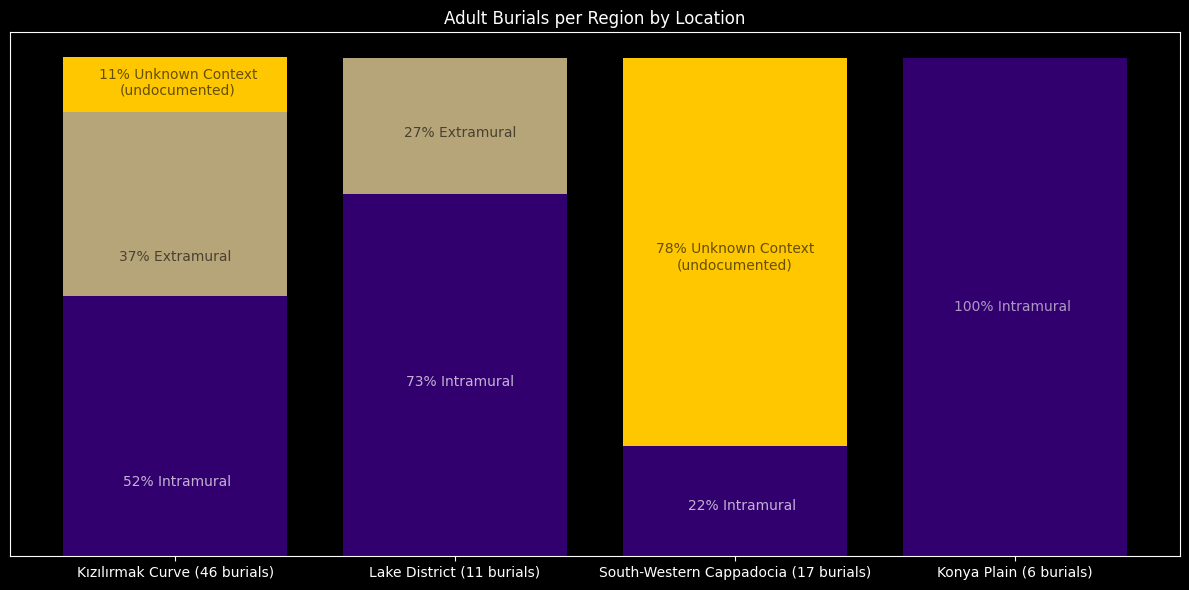

In [8]:
with plt.style.context('dark_background'):
    plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
    fig, ax = plt.subplots(figsize=(12,6))
    
    subregion= ['Kızılırmak Curve (46 burials)', 'Lake District (11 burials)', 'South-Western Cappadocia (17 burials)', 'Konya Plain (6 burials)']
    adults = [46, 11, 18, 6]
    subadults = [81, 56, 40, 14]
    adults_normalized= [46/(46+81), 11/(11+56), 18/(18+40), 6/(6+14)]
    subadults_normalized= [81/(46+81), 56/(11+56), 40/(18+40), 14/(6+14)]
    total_burials= [(46+81)/272, (11+56)/272, (18+40)/272, (6+14)/272]
    adult_burial_type = [[9, 1, 12, 0], [4, 0, 0, 0], [20, 10, 5, 1], [3, 0, 0, 0], [3, 0, 0, 5], [7, 0, 0, 0]]
    
    adult_pithos= np.array([0.2, 0.09, 0.71, 0.0])
    adult_cist= np.array([0.09, 0, 0, 0])
    adult_simple= np.array([0.43, 0.91, 0.29, 0.17])
    adult_refuse= np.array([0.07, 0, 0, 0])
    adult_other= np.array([0.07, 0, 0, 0.83])
    adult_unknown= np.array([0.14, 0, 0, 0])

    intramural=np.array([0.522, 0.727, 0.222, 1])
    extramural=np.array([0.370, 0.273, 0, 0])
    unknown_context=np.array([0.109, 0, 0.778, 0])
    
    # Bar 1
    ax.bar(subregion, intramural,label='Extramural Burials') #width=total_burials)
    # Bar 2 Stacked
    ax.bar(subregion, extramural, bottom=intramural, label='Intramural Burials') #width=total_burials) # illustrating: bottom
    # Bar 3 Stacked
    ax.bar(subregion, unknown_context, bottom=intramural + extramural, label='Unknown Context')
    ax.set_title("Adult Burials per Region by Location", size= 12)
    ax.yaxis.set_visible(False)
    #ax.legend()


    #Labels Kızılırmak Curve
    ax.text(0.20, 
            0.15,
            '52% Intramural',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(0.20, 
            0.60,
            '37% Extramural',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(0.01, 
            0.95,
            '11% Unknown Context\n(undocumented)',
            color='black', ha='center', va='center', alpha=0.6)
    

    #Labels Lake District
    ax.text(1.21, 
            0.35,
            '73% Intramural',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(1.22, 
            0.85,
            '27% Extramural',
            color='Black', ha='right', va='center', alpha=0.6)

    #Labels South-Western Cappadocia
    ax.text(2.22,
            0.10,
            '22% Intramural',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(2,
            0.60,
            '78% Unknown Context\n(undocumented)',
            color='black', ha='center', va='center', alpha=0.6)

    #Labels Konya Plain
    
    ax.text(3.20,
            0.50,
            '100% Intramural',
            color='white', ha='right', va='center', alpha=0.6)


    fig.tight_layout()
    plt.show()

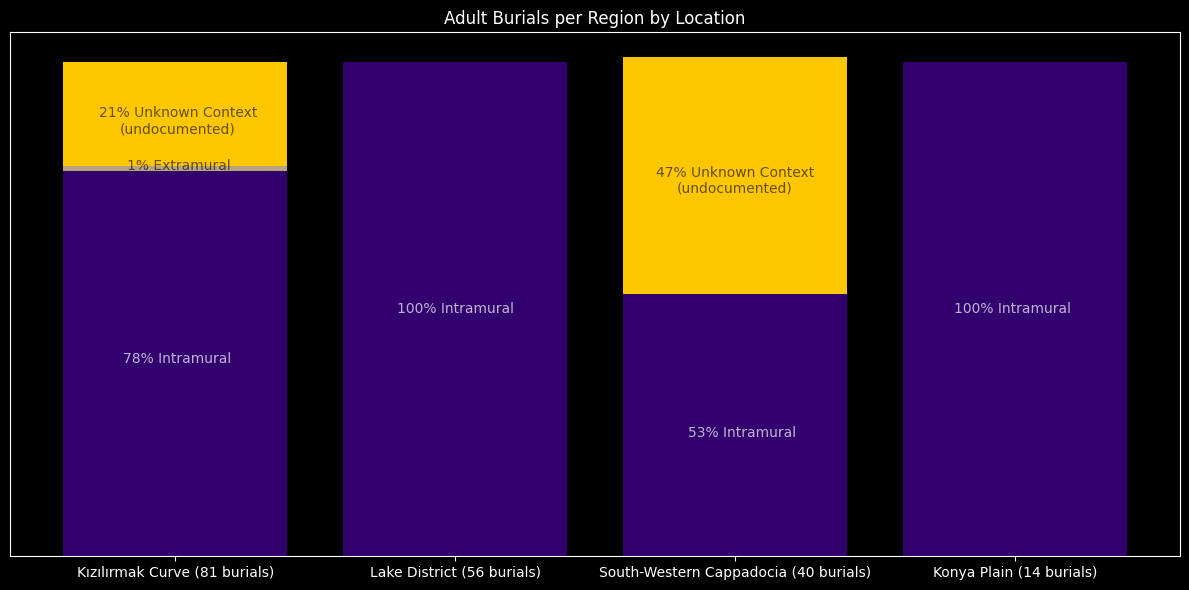

In [9]:
with plt.style.context('dark_background'):
    plt.rcParams["axes.prop_cycle"] = cycler('color', ['#32006E', '#B7A57A', '#FFC700', '#4B2E83', '#787276', '#E8D3A2'])
    fig, ax = plt.subplots(figsize=(12,6))
    
    subregion= ['Kızılırmak Curve (81 burials)', 'Lake District (56 burials)', 'South-Western Cappadocia (40 burials)', 'Konya Plain (14 burials)']
    adults = [46, 11, 18, 6]
    subadults = [81, 56, 40, 14]
    adults_normalized= [46/(46+81), 11/(11+56), 18/(18+40), 6/(6+14)]
    subadults_normalized= [81/(46+81), 56/(11+56), 40/(18+40), 14/(6+14)]
    total_burials= [(46+81)/272, (11+56)/272, (18+40)/272, (6+14)/272]
    adult_burial_type = [[9, 1, 12, 0], [4, 0, 0, 0], [20, 10, 5, 1], [3, 0, 0, 0], [3, 0, 0, 5], [7, 0, 0, 0]]
    
    adult_pithos= np.array([0.2, 0.09, 0.71, 0.0])
    adult_cist= np.array([0.09, 0, 0, 0])
    adult_simple= np.array([0.43, 0.91, 0.29, 0.17])
    adult_refuse= np.array([0.07, 0, 0, 0])
    adult_other= np.array([0.07, 0, 0, 0.83])
    adult_unknown= np.array([0.14, 0, 0, 0])

    intramural=np.array([0.78, 1, 0.53, 1])
    extramural=np.array([0.01, 0, 0, 0])
    unknown_context=np.array([0.21, 0, 0.48, 0])
    
    # Bar 1
    ax.bar(subregion, intramural,label='Extramural Burials') #width=total_burials)
    # Bar 2 Stacked
    ax.bar(subregion, extramural, bottom=intramural, label='Intramural Burials') #width=total_burials) # illustrating: bottom
    # Bar 3 Stacked
    ax.bar(subregion, unknown_context, bottom=intramural + extramural, label='Unknown Context')
    ax.set_title("Adult Burials per Region by Location", size= 12)
    ax.yaxis.set_visible(False)
    #ax.legend()


    #Labels Kızılırmak Curve
    ax.text(0.20, 
            0.40,
            '78% Intramural',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(0.20, 
            0.79,
            '1% Extramural',
            color='black', ha='right', va='center', alpha=0.6)
    ax.text(0.01, 
            0.88,
            '21% Unknown Context\n(undocumented)',
            color='black', ha='center', va='center', alpha=0.6)
    

    #Labels Lake District
    ax.text(1.21, 
            0.50,
            '100% Intramural',
            color='white', ha='right', va='center', alpha=0.7)
    

    #Labels South-Western Cappadocia
    ax.text(2.22,
            0.25,
            '53% Intramural',
            color='white', ha='right', va='center', alpha=0.7)
    ax.text(2,
            0.76,
            '47% Unknown Context\n(undocumented)',
            color='black', ha='center', va='center', alpha=0.6)

    #Labels Konya Plain
    
    ax.text(3.20,
            0.50,
            '100% Intramural',
            color='white', ha='right', va='center', alpha=0.7)


    fig.tight_layout()
    plt.show()